# **2. DATA UNDERSTANDING**

## **LIBRARIES**

In [1]:
! pip install adlfs azure-storage-blob

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.4/44.4 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.0/86.0 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.8/41.8 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 412.9/412.9 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.7/210.7 kB 17.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.3/55.3 kB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 187.9/187.9 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 116.9/116.9 kB 9.8 MB/s eta 0:00:00


In [2]:
# Standard Library
import os

# DATA MANIPULATION AND ANALYSIS
import pandas as pd
import numpy as np

# DATA VISUALISATION
import matplotlib.pyplot as plt
import seaborn as sns

# AZURE CLOUD STORAGE
from adlfs import AzureBlobFileSystem
from azure.storage.blob import BlobServiceClient

## **EXTRACT FROM AZURE BLOB STORAGE**

In [3]:
# Configuración de credenciales y cliente
AZURE_STORAGE_ACCOUNT = os.environ.get("AZURE_STORAGE_ACCOUNT", "researchprojectx24104515")
AZURE_STORAGE_KEY = os.environ.get("AZURE_STORAGE_KEY", "bxpexO6i+Hz6n1WiipTn+sTCuLPGMS1BogMERrIrHd16DpQ0GLfQ0R33yrSw4MxsDomq5yNMgw1o+AStlx/MjA==")
CONTAINER_NAME = "weather"

connection_string = f"DefaultEndpointsProtocol=https;AccountName={AZURE_STORAGE_ACCOUNT};AccountKey={AZURE_STORAGE_KEY};EndpointSuffix=core.windows.net"
blob_service_client = BlobServiceClient.from_connection_string(connection_string)
container_client = blob_service_client.get_container_client(CONTAINER_NAME)

fs = AzureBlobFileSystem(
    account_name=AZURE_STORAGE_ACCOUNT,
    account_key=AZURE_STORAGE_KEY
)

# Load CSV from Blob Storage
def load_csv(container_client, blob_name: str) -> pd.DataFrame:
    blob_client = container_client.get_blob_client(blob_name)
    stream = blob_client.download_blob()
    data_bytes = stream.readall()
    data_str = data_bytes.decode('utf-8')
    lines = data_str.splitlines()

    # Match index as column name
    for idx, line in enumerate(lines):
        if line.lower().startswith("date,"):
            header_idx = idx
            break
    else:
        raise ValueError("Header line starting with 'date,' not found in blob.")

    # Title and columns
    columns = lines[header_idx].split(',')
    rows = []
    for line in lines[header_idx + 1:]:
        parts = line.split(',')
        if len(parts) != len(columns):
            continue
        rows.append(dict(zip(columns, parts)))

    data = pd.DataFrame(rows)

    # Datetime column
    data["date"] = pd.to_datetime(data["date"], format="%d-%b-%Y %H:%M", errors="coerce", dayfirst=True)
    numeric_cols = [c for c in data.columns if c not in ["date"]]
    for col in numeric_cols:
        data[col] = pd.to_numeric(data[col], errors="coerce")

    return data

# Load
data = load_csv(container_client, "weather-dublin.csv")

## **EXPLORATORY DATA ANALYSIS**

In [4]:
data.describe()

,date,ind,rain,temp,wetb,dewpt,vappr,rhum,msl
count,188832,188832.000000,187772.000000,187758.000000,187633.000000,187633.000000,187633.000000,187633.000000,187756.000000
mean,2014-05-24 00:30:00,0.025398,0.088185,10.219814,8.639803,6.925419,10.399543,80.830344,1013.504751
min,2003-08-16 01:00:00,0.000000,0.000000,-10.400000,-10.600000,-12.400000,2.400000,21.000000,954.500000
25%,2009-01-03 00:45:00,0.000000,0.000000,6.500000,5.400000,3.600000,7.900000,73.000000,1005.900000
50%,2014-05-24 00:30:00,0.000000,0.000000,10.300000,8.800000,7.100000,10.100000,83.000000,1014.700000
75%,2019-10-12 00:15:00,0.000000,0.000000,14.000000,12.100000,10.300000,12.600000,91.000000,1022.200000
max,2025-03-01 00:00:00,4.000000,39.600000,32.500000,21.600000,19.600000,22.700000,100.000000,1048.000000
std,NaN,0.317724,0.429709,5.223184,4.543885,4.578572,3.188577,12.844798,12.450231


In [5]:
data.head()

,date,ind,rain,temp,wetb,dewpt,vappr,rhum,msl
0,2003-08-16 01:00:00,0,0.0,9.2,8.9,8.5,11.1,95.0,1021.9
1,2003-08-16 02:00:00,0,0.0,9.0,8.7,8.5,11.1,96.0,1021.7
2,2003-08-16 03:00:00,0,0.0,8.2,8.0,7.7,10.5,96.0,1021.2
3,2003-08-16 04:00:00,0,0.0,8.4,8.1,7.9,10.7,97.0,1021.2
4,2003-08-16 05:00:00,0,0.0,7.7,7.5,7.3,10.2,97.0,1021.1


In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188832 entries, 0 to 188831
Data columns (total 9 columns):
 #   Column  Non-Null Count   Dtype         
---  ------  --------------   -----         
 0   date    188832 non-null  datetime64[ns]
 1   ind     188832 non-null  int64         
 2   rain    187772 non-null  float64       
 3   temp    187758 non-null  float64       
 4   wetb    187633 non-null  float64       
 5   dewpt   187633 non-null  float64       
 6   vappr   187633 non-null  float64       
 7   rhum    187633 non-null  float64       
 8   msl     187756 non-null  float64       
dtypes: datetime64[ns](1), float64(7), int64(1)
memory usage: 13.0 MB


### **HOURLY PATTERNS**

In [7]:
def plot_time_series_grid(data, datetime_col="date", exclude_cols=None, n_cols=3, figsize_per_row=3):
    if exclude_cols is None:
        exclude_cols = ["hour", "weekday", "month", "year"]
    plt.style.use("ggplot")
    numeric_cols = data.select_dtypes(include=np.number).columns.tolist() # Numeric columns
    location_cols = [col for col in numeric_cols if col not in exclude_cols]
    n_rows = int(np.ceil(len(location_cols) / n_cols)) # Grid size
    # Subplots
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, figsize_per_row * n_rows), sharex=True)
    axes = axes.flatten()
    # Columns plot
    for i, col in enumerate(location_cols):
        data.plot(x=datetime_col, y=col, ax=axes[i], legend=False)
        axes[i].set_title(f"Variable at {col}", fontsize=8)
        axes[i].set_xlabel("Date")
        axes[i].set_ylabel("Count")
    plt.tight_layout()
    plt.show()

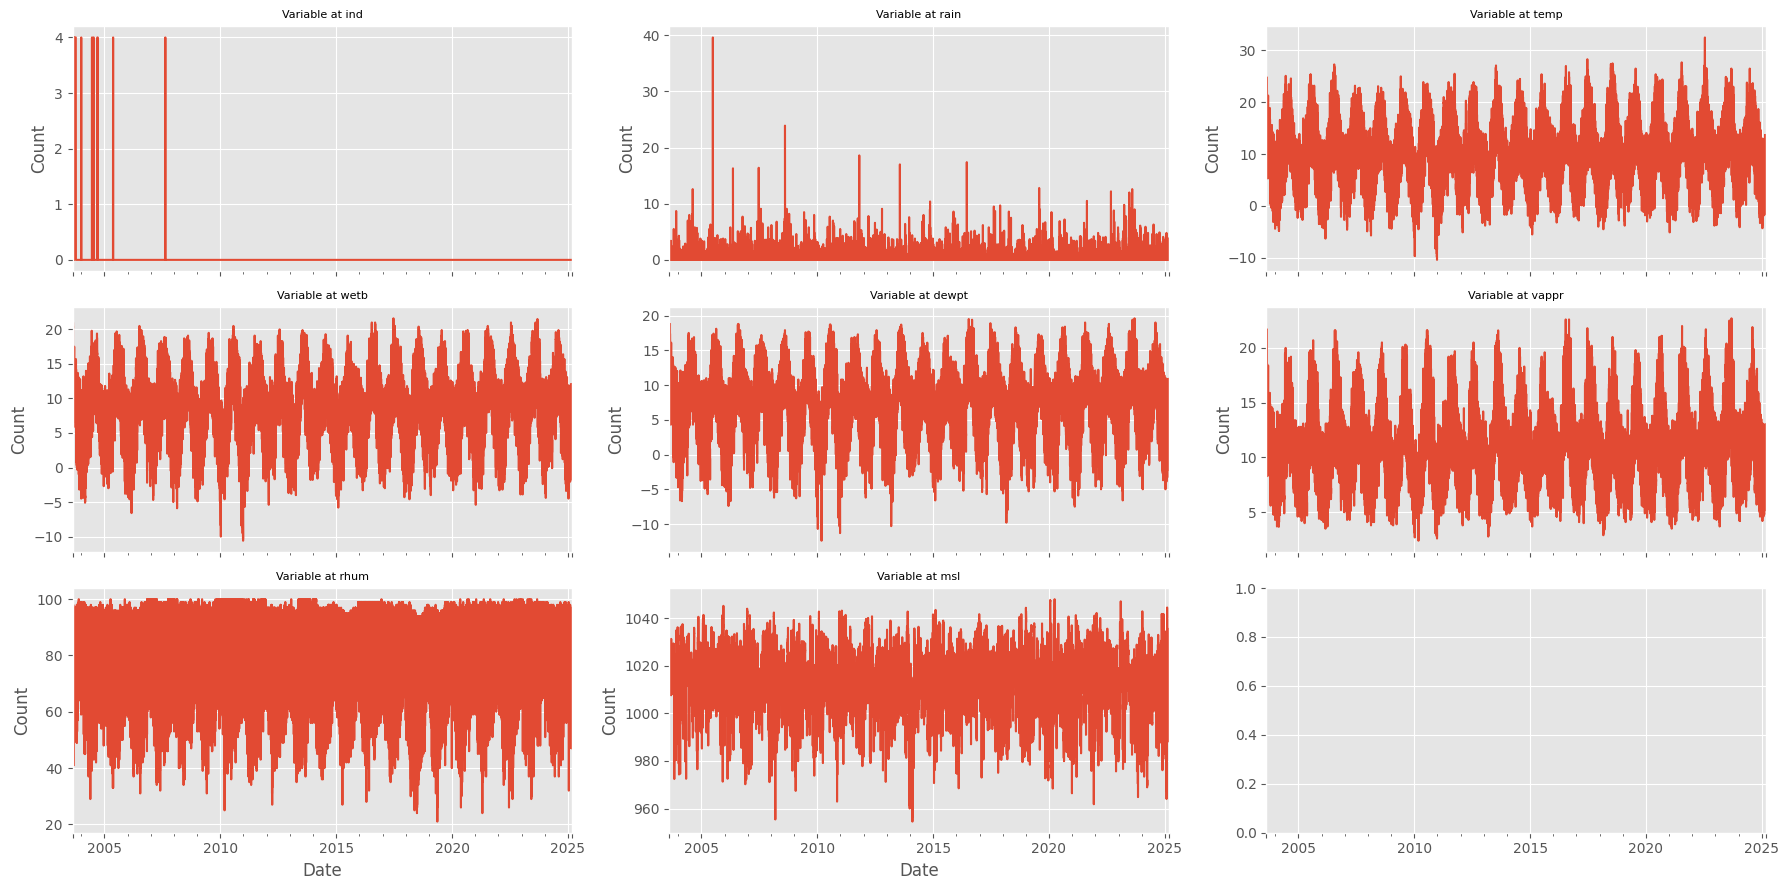

In [8]:
plot_time_series_grid(data)

**RAIN (mm)**

Unlike cyclical patterns in temperature, rainfall in Dublin is considered irregular and episodic, which is considered in the abrupt peaks, representing intense rainfall events.
Seasonal patterns are not easily distinguised. Considering an anomaly happened between 2004 and 2008 reaching almost 40mm of rainfall, in comparison to the overall density of vertical lines suggesting rain is frequent in Dublin and most rainfall happens in a low intensity (less than 5mm) but there are regular episodes with moderate to heavy rainfall over the years.


**RELATIVE HUMIDITY**

The relative humidity in Dublin range is generally between 20%  and 100% during the driest and most humid periods, respectively. Considering  it remains in a high level above 80-90%, as a characteristic of the Irish climate.
There is presence of seasonal variability, where lower relative humidity happens during warmer seasons. Moreover, a pattern of fast changes in relative humidity is shown indicating there are significant daily shifts in atmospheric conditiions.

Overall, there is a high relative humidity throughout the year, with frequent rainfall, shifting atmospheric conditions and rare incidents of extreme dryness.

**TEMPERATURE**

The graph indicates that there is an annual cylical pattern where temperatures increase in summer time (peaks) and decrease in winter (troughs), which creates a wave-like pattern across time.

Also, some of the peaks and thoughs over the years indicate anomalies within weather conditions that leaded temperature to reach the coldest winter (-10°C) between 2010 and 2012, and the hotest summer (30°C) between 2022 and 2023.

### **CORRELATION MATRIX**

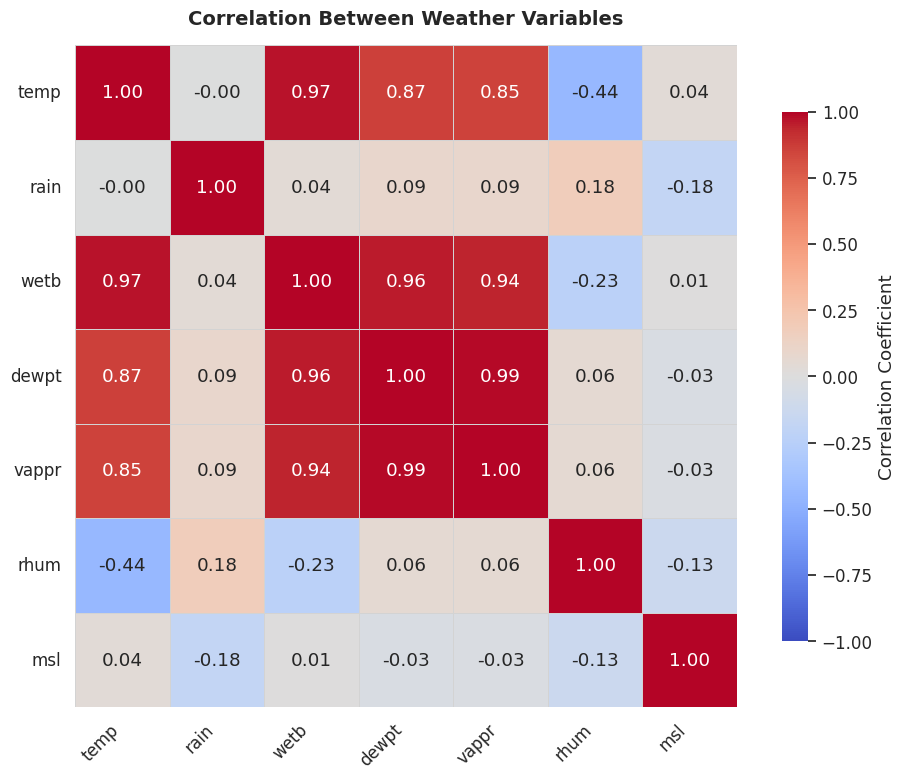

In [9]:
numeric_cols = ["temp", "rain", "wetb", "dewpt", "vappr", "rhum", "msl"]
corr = data[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.set(style="whitegrid", font_scale=1.1)

heatmap = sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    linewidths=0.5,
    linecolor="lightgray",
    square=True,
    cbar_kws={"shrink": 0.8, "label": "Correlation Coefficient"}
)

plt.title("Correlation Between Weather Variables", fontsize=14, weight="bold", pad=15)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


Temperature indicates a very high positive correlation with wet bulb temperature (0.97), dew point temperature (0.87), and  vapour pressure (0.85), but a moderate low negative correlation against relative humidity (-0.44). Against the rest of the variables, temperatures has a very low correlation level.
Relative humidity indicates negative correlation with temperature (-0.44) and wet bulb temperature (-0.23), which indicates a consistent fact, that more warmer air can hold more water vapor before becoming saturated (reaching 100% relative humidity).

Source:
https://sealevel.jpl.nasa.gov/ocean-observation/understanding-climate/air-and-water/?utm_source=chatgpt.com

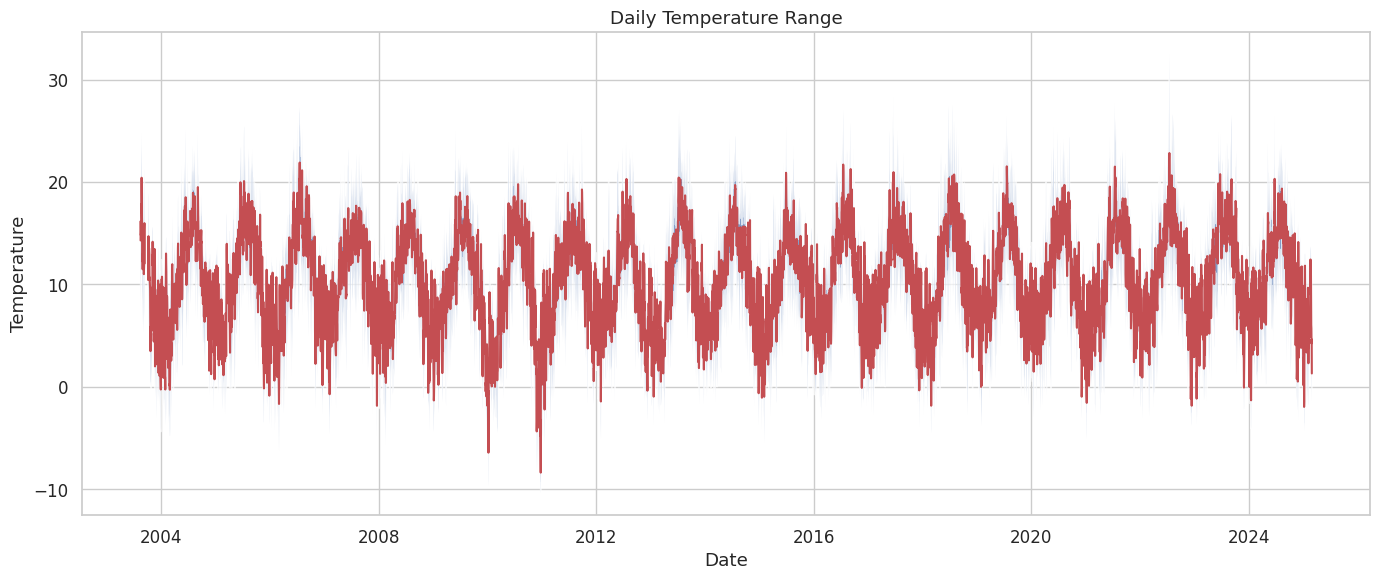

In [10]:
# Group by date (day) and calculate min, max, mean temperature
daily_temp = data.groupby(data["date"].dt.date).agg({
    "temp": ["min", "max", "mean"]
})
daily_temp.columns = ["temp_min", "temp_max", "temp_mean"]
daily_temp = daily_temp.reset_index()

# Plot
plt.figure(figsize=(14, 6))
plt.fill_between(daily_temp["date"], daily_temp["temp_min"],
                 daily_temp["temp_max"], alpha=0.7)
plt.plot(daily_temp["date"], daily_temp["temp_mean"], "r-")
plt.title("Daily Temperature Range")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.grid(True)
plt.tight_layout()
plt.show()

The red line indicates the mean daily temperature across the years in °C. The light blue shade indicates the range between the daily minimun and maximum temperature. Also, ocassionally, temperatures in winter drops below 0 °C. A seasonal pattern is observed and the variability of temperature throughout time in Dublin.

### **TEMPORAL FEATURES EXTRACTION**

In [11]:
# Extract datetime components
def temporal_components(data: pd.DataFrame) -> pd.DataFrame:
    # Temporal components
    data["year"] = data["date"].dt.year
    data["month"] = data["date"].dt.month
    data["day"] = data["date"].dt.day
    data["hour"] = data["date"].dt.hour
    data["weekday"] = data["date"].dt.weekday
    return data

In [12]:
data["date"].head()

,date
0,2003-08-16 01:00:00
1,2003-08-16 02:00:00
2,2003-08-16 03:00:00
3,2003-08-16 04:00:00
4,2003-08-16 05:00:00


In [13]:
temporal_components(data)

,date,ind,rain,temp,wetb,dewpt,vappr,rhum,msl,year,month,day,hour,weekday
0,2003-08-16 01:00:00,0,0.0,9.2,8.9,8.5,11.1,95.0,1021.9,2003,8,16,1,5
1,2003-08-16 02:00:00,0,0.0,9.0,8.7,8.5,11.1,96.0,1021.7,2003,8,16,2,5
2,2003-08-16 03:00:00,0,0.0,8.2,8.0,7.7,10.5,96.0,1021.2,2003,8,16,3,5
3,2003-08-16 04:00:00,0,0.0,8.4,8.1,7.9,10.7,97.0,1021.2,2003,8,16,4,5
4,2003-08-16 05:00:00,0,0.0,7.7,7.5,7.3,10.2,97.0,1021.1,2003,8,16,5,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188827,2025-02-28 20:00:00,0,0.0,6.0,3.6,-0.4,5.9,63.0,1028.6,2025,2,28,20,4
188828,2025-02-28 21:00:00,0,0.0,4.4,2.7,-0.2,6.0,71.0,1029.0,2025,2,28,21,4
188829,2025-02-28 22:00:00,0,0.0,4.1,2.7,0.4,6.3,76.0,1029.4,2025,2,28,22,4
188830,2025-02-28 23:00:00,0,0.0,2.8,1.7,-0.2,6.0,80.0,1029.6,2025,2,28,23,4


### **AVERAGE TEMPERATURE PER HOUR**

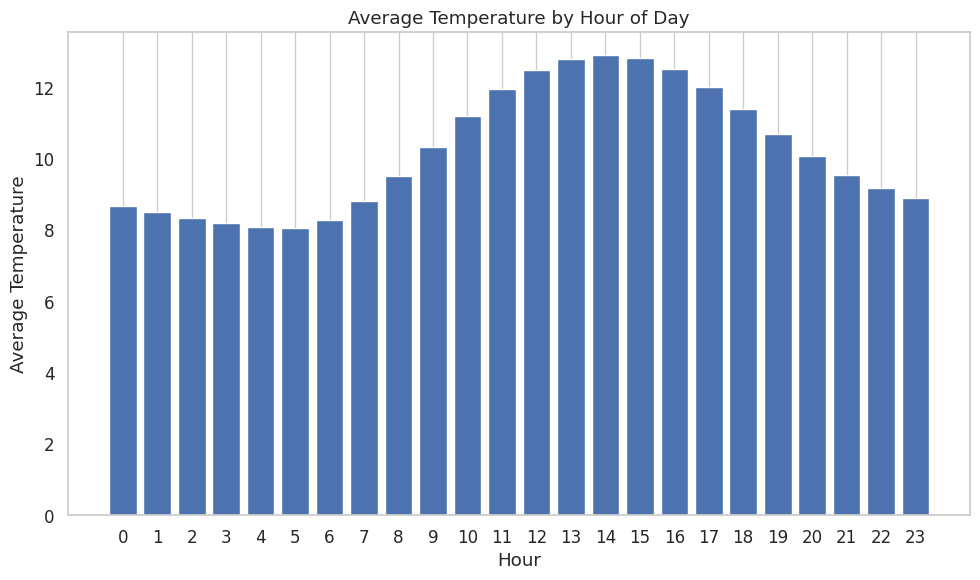

In [14]:
hourly_temp = data.groupby("hour")["temp"].mean()

plt.figure(figsize=(10, 6))
plt.bar(hourly_temp.index, hourly_temp.values)
plt.title("Average Temperature by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Average Temperature")
plt.xticks(range(0, 24))
plt.grid(axis="y")
plt.tight_layout()
plt.show()

A diurnal cycle is observed through the bar chart where between 00:00 and 06:00 has the lowest temperatures and then tends to increase reaching its highest temperature at 14:00 to decrease after as a cycle.

### **AVERAGE TEMPERATURE BY HOUR IN THE LAST SIX YEARS**

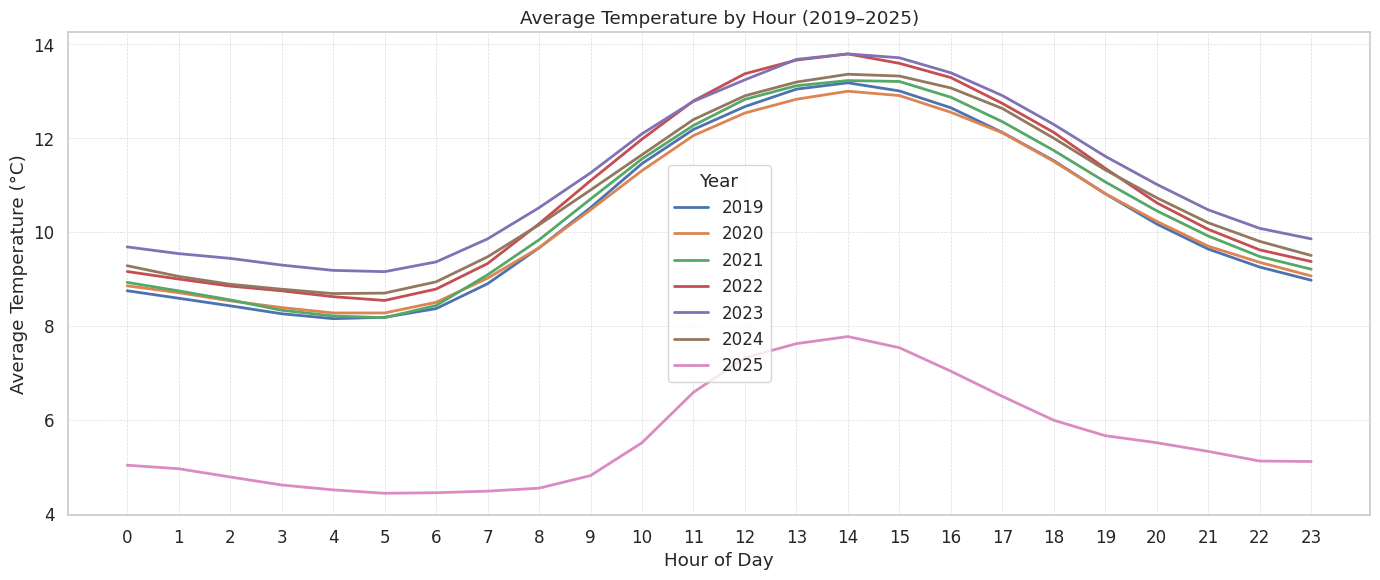

In [15]:
data["date"] = pd.to_datetime(data["date"], format="%d-%b-%Y %H:%M", errors="coerce", dayfirst=True)

# Data from years 2019 to 2025
filtered = data[(data["year"] >= 2019) & (data["year"] <= 2025)]

# Years groups with average temperature
yhourly_temp = filtered.groupby(["year", "hour"])["temp"].mean().unstack(level=0)

# Charts of average temperature by year
plt.figure(figsize=(14, 6))
for year in yhourly_temp.columns:
    plt.plot(
        yhourly_temp.index,
        yhourly_temp[year],
        label=str(year),
        linewidth=2
    )

plt.title("Average Temperature by Hour (2019–2025)")
plt.xlabel("Hour of Day")
plt.ylabel("Average Temperature (°C)")
plt.xticks(range(0, 24))
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

Overall, the same temperature trend is observed for the years 2019 to 2025, within the hourly cycles.

### **AVERAGE TEMPERATURE BY MONTH IN THE LAST SIX YEARS**

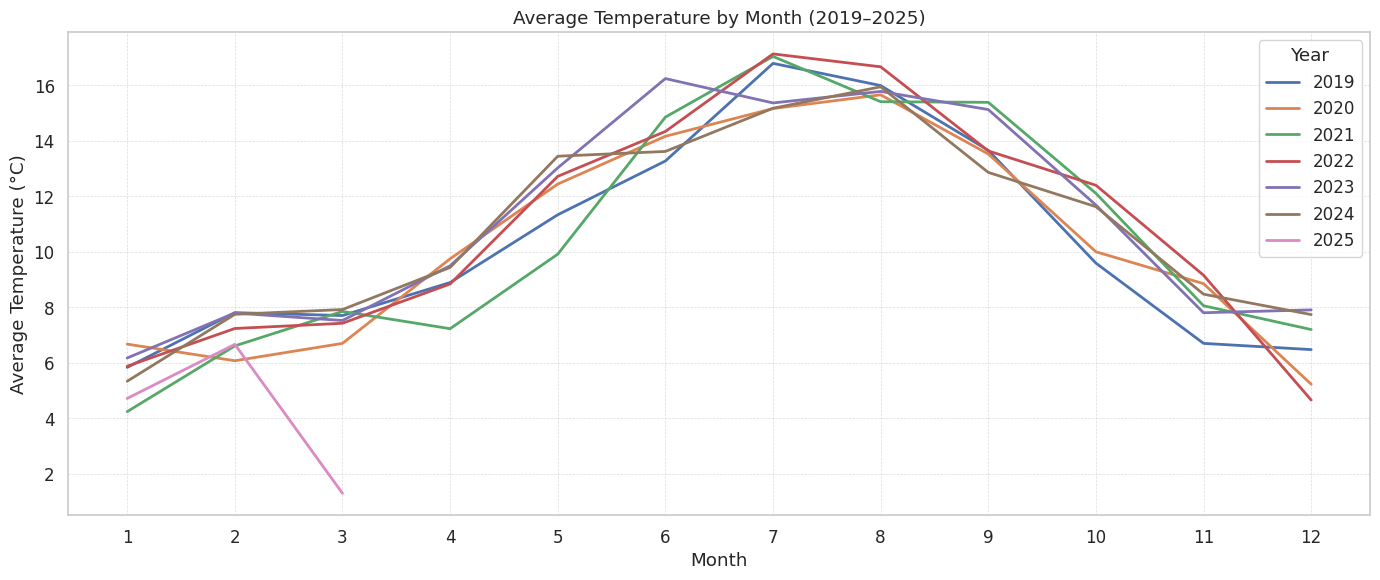

In [16]:
# Group by year and month and average temperature
mhourly_tem = filtered.groupby(["year", "month"])["temp"].mean().unstack(level=0)

# Rows and columns for subplots
num_years = len(mhourly_tem.columns)
num_cols = 3  # Number of columns in the subplot grid
num_rows = int(np.ceil(num_years / num_cols))  # Calculate the number of rows needed

# Separate charts by year
plt.figure(figsize=(14, 6))
for year in mhourly_tem.columns:
    plt.plot(
        mhourly_tem.index,
        mhourly_tem[year],
        label=str(year),
        linewidth=2
    )

# Chart
plt.title("Average Temperature by Month (2019–2025)")
plt.xlabel("Month")
plt.ylabel("Average Temperature (°C)")
plt.xticks(range(1, 13))
plt.grid(True, linestyle="--", linewidth=0.5, alpha=0.7)
plt.legend(title="Year")
plt.tight_layout()
plt.show()

Overall, the same temperature trend is observed for the months of years 2019 to 2025, within the temperature cycles.

### **AVERAGE ANNUAL TEMPERATURE TREND BY YEAR**

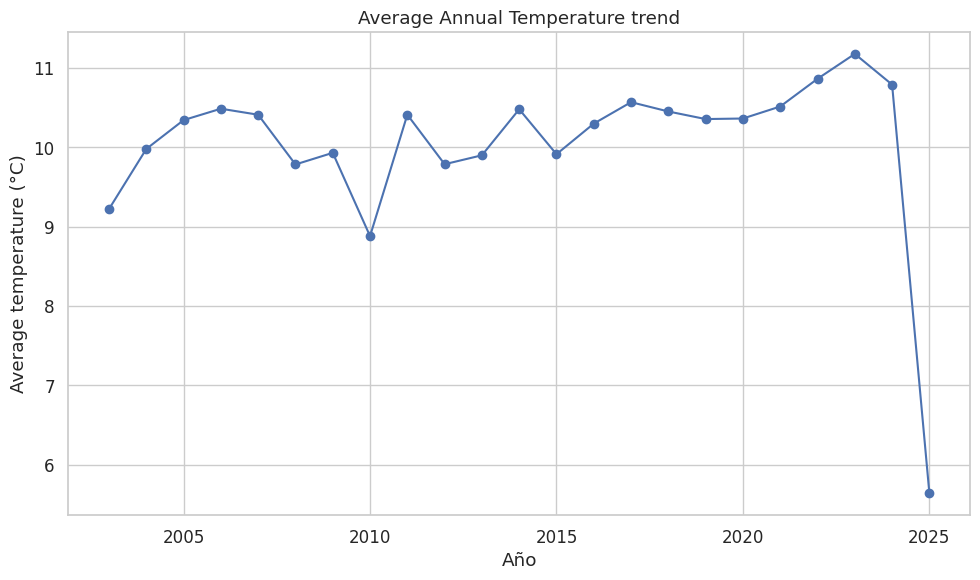

In [17]:
# Average Annual Temperature trend
annual_temp = data.groupby("year")["temp"].mean()

plt.figure(figsize=(10, 6))
plt.plot(annual_temp.index, annual_temp.values, marker="o", linestyle="-")
plt.title("Average Annual Temperature trend")
plt.xlabel("Año")
plt.ylabel("Average temperature (°C)")
plt.grid(True)
plt.tight_layout()
plt.show()


Overall, the temperatures suggests a shift in the trends of temperature over the years, rising temperatures after 2020 indicates possible meteorological phenomenon that affects the lowest and highest temperatures, registering higher than previous years and affecting the average.

Year 2025 indicates the lowest average temperature considering the data from that year is not from the whole year.

### **HEAT MAP: AVERAGE TEMPERATURE BY HOUR AND MONTH**

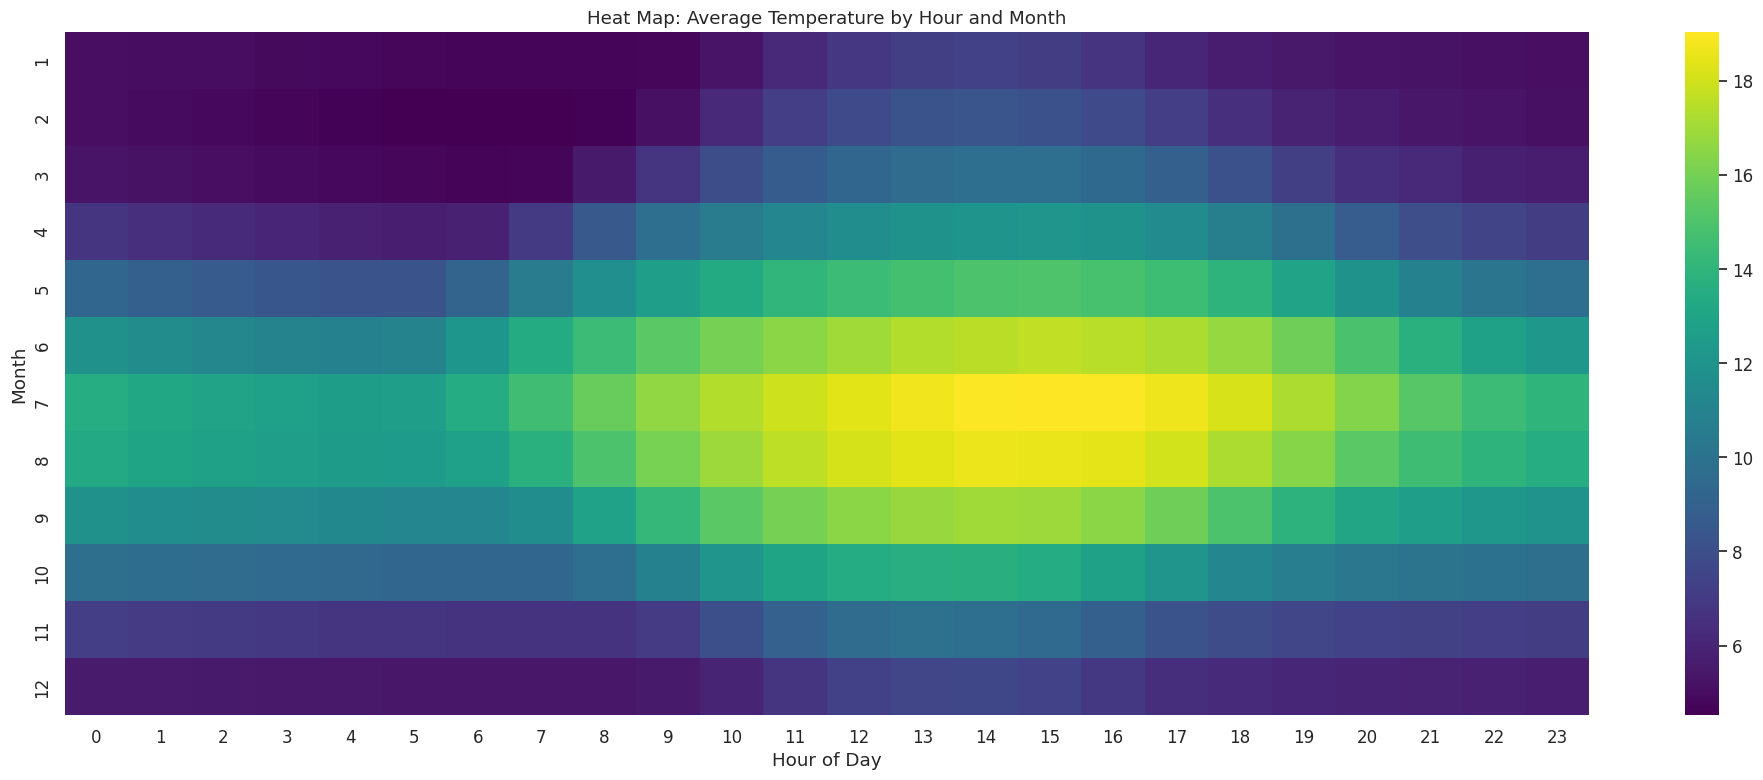

In [31]:
# Create matrix for heatmap (hour x month)
pivot_temp = data.groupby(["month", "hour"])["temp"].mean().unstack()

plt.figure(figsize=(20, 8))
sns.heatmap(pivot_temp, cmap="viridis", annot=False, fmt=".1f")
plt.title("Heat Map: Average Temperature by Hour and Month")
plt.xlabel("Hour of Day")
plt.ylabel("Month")
plt.tight_layout()
plt.show()

Per hour and month, the highest temperatures occurs between 7:00 and 19:00 reaching the highest peak at 14:00 during the monts of May and October.

### **FREQUENCY OF EXTREME TEMPERATURES EVENTS BY YEAR**

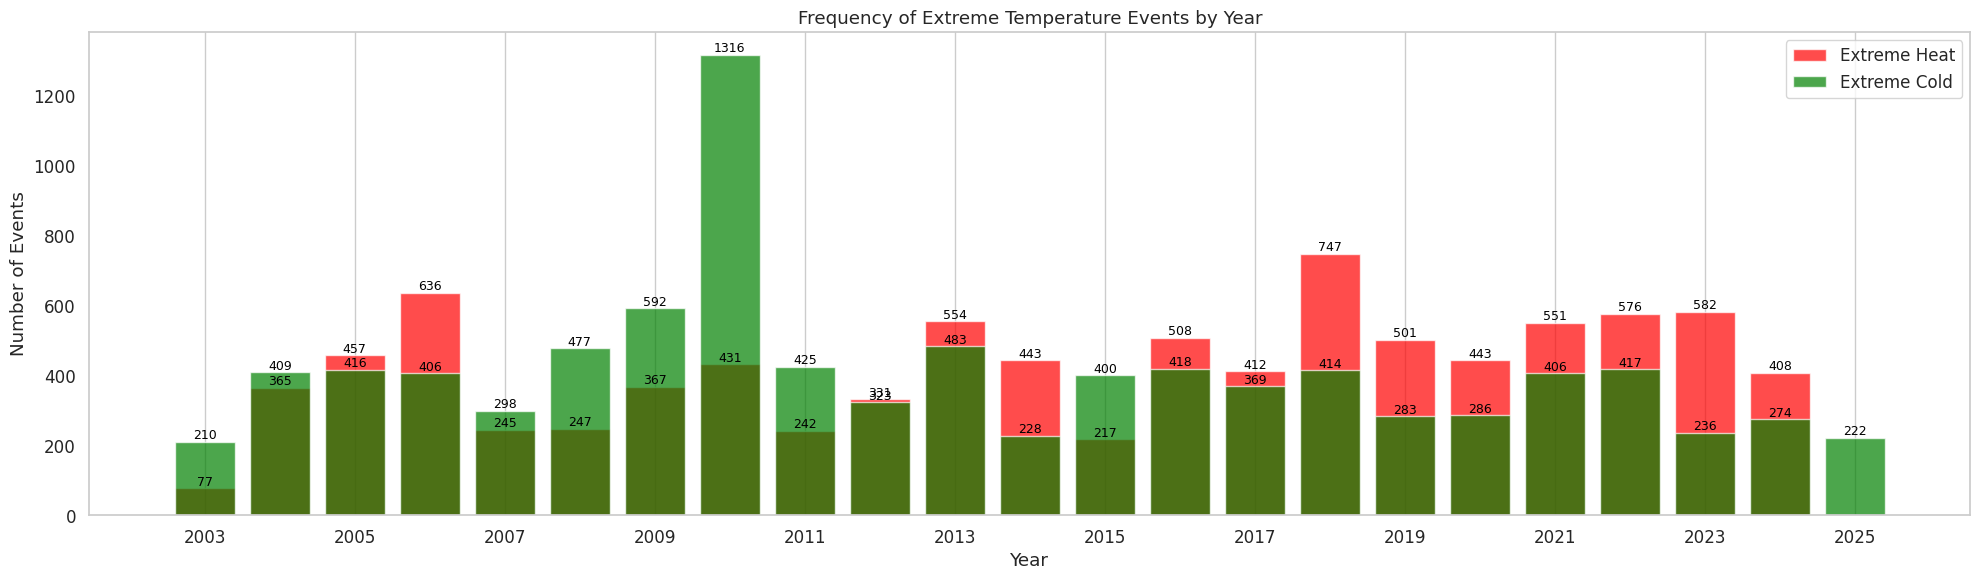

In [19]:
# Calculate percentiles to identify extreme temperatures
q_low = data["temp"].quantile(0.05)
q_high = data["temp"].quantile(0.95)

# Filter days with extreme temperatures
extreme_cold = data[data["temp"] < q_low]
extreme_hot = data[data["temp"] > q_high]

# Count extreme events by year
cold_events_by_year = extreme_cold.groupby("year").size()
hot_events_by_year = extreme_hot.groupby("year").size()
years = cold_events_by_year.index

plt.figure(figsize=(20, 6))
bars_hot = plt.bar(hot_events_by_year.index, hot_events_by_year, color="red", alpha=0.7, label="Extreme Heat")
bars_cold = plt.bar(cold_events_by_year.index, cold_events_by_year, color="green", alpha=0.7, label="Extreme Cold")

plt.title("Frequency of Extreme Temperature Events by Year")
plt.xticks(years[::2])
plt.xlabel("Year")
plt.ylabel("Number of Events")
plt.legend()
plt.grid(axis="y")
plt.tight_layout()


for bar in bars_hot:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}',
             ha='center', va='bottom', fontsize=9, color='black')

# Agrega el label count encima de cada barra de frío extremo
for bar in bars_cold:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height, f'{int(height)}',
             ha='center', va='bottom', fontsize=9, color='black')

plt.show()

Between 2007 and 2012 the number of extreme cold temperature events tends to be higher than the extreme hot temperature as in other years, which indicates a latent increase in temperatures in Dublin area.

### **TOTAL MISSING VALUES BY VARIABLE**

In [20]:
data["date"] = data["date"].dt.strftime("%d/%m/%Y %H:%M")

In [21]:
data.isnull().sum()

,0
date,0
ind,0
rain,1060
temp,1074
wetb,1199
dewpt,1199
vappr,1199
rhum,1199
msl,1076
year,0


### **RECORDS WITH MISSING VALUES**

In [22]:
missing_values = data[data.isnull().any(axis=1)]
missing_values.head()

,date,ind,rain,temp,wetb,dewpt,vappr,rhum,msl,year,month,day,hour,weekday
384,01/09/2003 01:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,9,1,1,0
385,01/09/2003 02:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,9,1,2,0
386,01/09/2003 03:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,9,1,3,0
387,01/09/2003 04:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,9,1,4,0
388,01/09/2003 05:00,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2003,9,1,5,0


The dates where the values are missing are mainly from the years 2003, 2004, 2005 and 2007, which are not considered in the timeframe of this study. Although, to evaluate how weather conditions have change in the last two decades, missing values are key for a descriptive analysis.

### **INTERPOLATION OF MISSING DATA**

In [23]:
# Lineal interpolation for all numerical columns
weather = data.interpolate(method="linear", limit_direction="both")
weather.head()

/tmp/ipython-input-1207239546.py:2: FutureWarning: DataFrame.interpolate with object dtype is deprecated and will raise in a future version. Call obj.infer_objects(copy=False) before interpolating instead.
  weather = data.interpolate(method="linear", limit_direction="both")


,date,ind,rain,temp,wetb,dewpt,vappr,rhum,msl,year,month,day,hour,weekday
0,16/08/2003 01:00,0,0.0,9.2,8.9,8.5,11.1,95.0,1021.9,2003,8,16,1,5
1,16/08/2003 02:00,0,0.0,9.0,8.7,8.5,11.1,96.0,1021.7,2003,8,16,2,5
2,16/08/2003 03:00,0,0.0,8.2,8.0,7.7,10.5,96.0,1021.2,2003,8,16,3,5
3,16/08/2003 04:00,0,0.0,8.4,8.1,7.9,10.7,97.0,1021.2,2003,8,16,4,5
4,16/08/2003 05:00,0,0.0,7.7,7.5,7.3,10.2,97.0,1021.1,2003,8,16,5,5


In [24]:
missing_values = weather[weather.isnull().any(axis=1)]
missing_values

,date,ind,rain,temp,wetb,dewpt,vappr,rhum,msl,year,month,day,hour,weekday


In [25]:
def add_prefix_to_columns(data, prefix="WTH_", exclude_col= "date and time"):
    data = data.copy()
    if "date" or "Date and time" or "Date & time" in data.columns:
        data.rename(columns={"date": "date and time", "date & time": "date and time" }, inplace=True)

    data.rename(columns={col: f"{prefix}{col}" for col in data.columns if col != exclude_col}, inplace=True)
    return data

weather.drop(columns=["hour", "day", "weekday", "month", "year"], errors="ignore", inplace=True)
weather = add_prefix_to_columns(weather)
weather

,date and time,WTH_ind,WTH_rain,WTH_temp,WTH_wetb,WTH_dewpt,WTH_vappr,WTH_rhum,WTH_msl
0,16/08/2003 01:00,0,0.0,9.2,8.9,8.5,11.1,95.0,1021.9
1,16/08/2003 02:00,0,0.0,9.0,8.7,8.5,11.1,96.0,1021.7
2,16/08/2003 03:00,0,0.0,8.2,8.0,7.7,10.5,96.0,1021.2
3,16/08/2003 04:00,0,0.0,8.4,8.1,7.9,10.7,97.0,1021.2
4,16/08/2003 05:00,0,0.0,7.7,7.5,7.3,10.2,97.0,1021.1
...,...,...,...,...,...,...,...,...,...
188827,28/02/2025 20:00,0,0.0,6.0,3.6,-0.4,5.9,63.0,1028.6
188828,28/02/2025 21:00,0,0.0,4.4,2.7,-0.2,6.0,71.0,1029.0
188829,28/02/2025 22:00,0,0.0,4.1,2.7,0.4,6.3,76.0,1029.4
188830,28/02/2025 23:00,0,0.0,2.8,1.7,-0.2,6.0,80.0,1029.6


In [26]:
# Percentage of 0 values per column
zero_percent = (data == 0).sum() / len(data) * 100

# Display nicely
print("Percentage of 0 values per column:")
print(zero_percent.sort_values(ascending=False))

Percentage of 0 values per column:
ind        99.365044
rain       86.193548
weekday    14.285714
hour        4.166667
dewpt       0.332041
wetb        0.178995
temp        0.131863
date        0.000000
vappr       0.000000
rhum        0.000000
year        0.000000
msl         0.000000
day         0.000000
month       0.000000
dtype: float64


In [27]:
# Consider only data after 2019 for study purposes
weather["date and time"] = pd.to_datetime(weather["date and time"], dayfirst=True)
weather = weather[weather["date and time"] >= "2019-01-01"].copy()

# Drop redundant column
weather.drop(columns=["WTH_ind"], errors="ignore", inplace=True)
weather.reset_index(drop=True, inplace=True)

# Check dataframe after 2019
weather

,date and time,WTH_rain,WTH_temp,WTH_wetb,WTH_dewpt,WTH_vappr,WTH_rhum,WTH_msl
0,2019-01-01 00:00:00,0.0,9.6,7.8,5.6,9.1,76.0,1035.1
1,2019-01-01 01:00:00,0.0,8.6,7.1,5.3,8.9,79.0,1035.1
2,2019-01-01 02:00:00,0.0,8.3,6.9,5.3,8.9,81.0,1034.9
3,2019-01-01 03:00:00,0.0,9.1,7.6,5.8,9.2,79.0,1035.5
4,2019-01-01 04:00:00,0.0,9.2,7.7,5.9,9.3,79.0,1035.7
...,...,...,...,...,...,...,...,...
54020,2025-02-28 20:00:00,0.0,6.0,3.6,-0.4,5.9,63.0,1028.6
54021,2025-02-28 21:00:00,0.0,4.4,2.7,-0.2,6.0,71.0,1029.0
54022,2025-02-28 22:00:00,0.0,4.1,2.7,0.4,6.3,76.0,1029.4
54023,2025-02-28 23:00:00,0.0,2.8,1.7,-0.2,6.0,80.0,1029.6


In [28]:
weather

,date and time,WTH_rain,WTH_temp,WTH_wetb,WTH_dewpt,WTH_vappr,WTH_rhum,WTH_msl
0,2019-01-01 00:00:00,0.0,9.6,7.8,5.6,9.1,76.0,1035.1
1,2019-01-01 01:00:00,0.0,8.6,7.1,5.3,8.9,79.0,1035.1
2,2019-01-01 02:00:00,0.0,8.3,6.9,5.3,8.9,81.0,1034.9
3,2019-01-01 03:00:00,0.0,9.1,7.6,5.8,9.2,79.0,1035.5
4,2019-01-01 04:00:00,0.0,9.2,7.7,5.9,9.3,79.0,1035.7
...,...,...,...,...,...,...,...,...
54020,2025-02-28 20:00:00,0.0,6.0,3.6,-0.4,5.9,63.0,1028.6
54021,2025-02-28 21:00:00,0.0,4.4,2.7,-0.2,6.0,71.0,1029.0
54022,2025-02-28 22:00:00,0.0,4.1,2.7,0.4,6.3,76.0,1029.4
54023,2025-02-28 23:00:00,0.0,2.8,1.7,-0.2,6.0,80.0,1029.6


In [29]:
def save_to_blob(data, filename):
    try:
        blob_name = f"{CONTAINER_NAME}/{filename}"
        csv_data = data.to_csv(index=False)
        with fs.open(blob_name, 'w') as f:
            f.write(csv_data)
        print(f"Saved to {blob_name}")
    except Exception as e:
        print(f"Error saving data to blob storage: {str(e)}")
        return False

In [30]:
CONTAINER_NAME = "preprocessed"

save_to_blob(weather, "weather.csv")

Saved to preprocessed/weather.csv
